In [1]:
import seaborn as sns 
import pandas as pd 

df = sns.load_dataset("attention")
df.head()

,Unnamed: 0,subject,attention,solutions,score
0,0,1,divided,1,2.0
1,1,2,divided,1,3.0
2,2,3,divided,1,3.0
3,3,4,divided,1,5.0
4,4,5,divided,1,4.0


In [2]:
df.describe()

,Unnamed: 0,subject,solutions,score
count,60.000000,60.000000,60.000000,60.000000
mean,29.500000,10.500000,2.000000,5.958333
std,17.464249,5.814943,0.823387,1.621601
min,0.000000,1.000000,1.000000,2.000000
25%,14.750000,5.750000,1.000000,5.000000
50%,29.500000,10.500000,2.000000,6.000000
75%,44.250000,15.250000,3.000000,7.000000
max,59.000000,20.000000,3.000000,9.000000


In [3]:
df.isnull().sum()

Unnamed: 0    0
subject       0
attention     0
solutions     0
score         0
dtype: int64

In [8]:
df = df.drop(columns = ["Unnamed: 0"]) 

In [10]:
df.head()

,subject,attention,solutions,score
0,1,divided,1,2.0
1,2,divided,1,3.0
2,3,divided,1,3.0
3,4,divided,1,5.0
4,5,divided,1,4.0


In [11]:
df.groupby("attention")["score"].mean()

attention
divided    5.116667
focused    6.800000
Name: score, dtype: float64

In [12]:
5 == 3

False

In [13]:
df[df["attention"] == "focused"]

,subject,attention,solutions,score
10,11,focused,1,6.0
11,12,focused,1,8.0
12,13,focused,1,6.0
13,14,focused,1,8.0
14,15,focused,1,8.0
15,16,focused,1,6.0
16,17,focused,1,7.0
17,18,focused,1,7.0
18,19,focused,1,5.0
19,20,focused,1,6.0


In [14]:
focused_scores = df[df["attention"] == "focused"]["score"]
divided_scores = df[df["attention"] == "divided"]["score"]

from scipy import stats 
t, p = stats.ttest_ind(focused_scores, divided_scores)

In [18]:
print(f"t = {t}, p = {p}")

t = 4.678215417179045, p = 1.7776522120812565e-05


In [19]:
df[df["subject"] == 1]

,subject,attention,solutions,score
0,1,divided,1,2.0
20,1,divided,2,4.0
40,1,divided,3,7.0


In [22]:
df[df["subject"] == 11]
df[df["subject"] == 4]

,subject,attention,solutions,score
3,4,divided,1,5.0
23,4,divided,2,7.0
43,4,divided,3,5.0


In [24]:
df.groupby(["attention" , "solutions"])["score"].mean()

attention  solutions
divided    1            4.00
           2            4.95
           3            6.40
focused    1            6.70
           2            7.00
           3            6.70
Name: score, dtype: float64

In [28]:
divided_sol1 = df[(df["attention"] == "divided") & (df["solutions"] == 1)]["score"]
divided_sol3 = df[(df["attention"] == "divided")&(df["solutions"] == 3)]["score"]

from scipy import stats
t, p = stats.ttest_rel(divided_sol1, divided_sol3)
print(f" t = {t}, p = {p}")

 t = -3.999999999999999, p = 0.00311042831038586


In [30]:
focused_sol1 = df[(df["attention"] == "focused") & (df["solutions"] == 1)]["score"]
focused_sol3 = df[(df["attention"] == "focused") & (df["solutions"] == 3)]["score"]

t, p = stats.ttest_rel(focused_sol1, focused_sol3)
print(f"t = {t} , p = {p}")

t = 0.0 , p = 1.0


In [31]:
df["score"].max()

9.0

In [32]:
df[df["score"] == 9]

,subject,attention,solutions,score
31,12,focused,2,9.0
52,13,focused,3,9.0


In [33]:
df[df["subject"] == 12]

,subject,attention,solutions,score
11,12,focused,1,8.0
31,12,focused,2,9.0
51,12,focused,3,8.0


In [35]:
df[df["subject"] == 13]

,subject,attention,solutions,score
12,13,focused,1,6.0
32,13,focused,2,5.0
52,13,focused,3,9.0


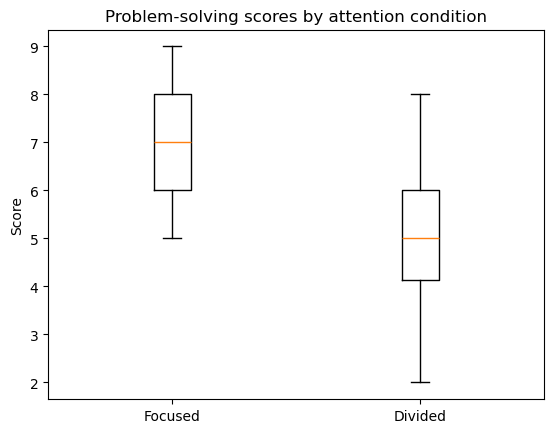

In [38]:
import matplotlib.pyplot as plt
plt.boxplot([focused_scores, divided_scores], tick_labels = ["Focused", "Divided"])
plt.ylabel("Score")
plt.title("Problem-solving scores by attention condition")
plt.show()

Text(0.5, 1.0, 'Problem-solving scores by Attention condition')

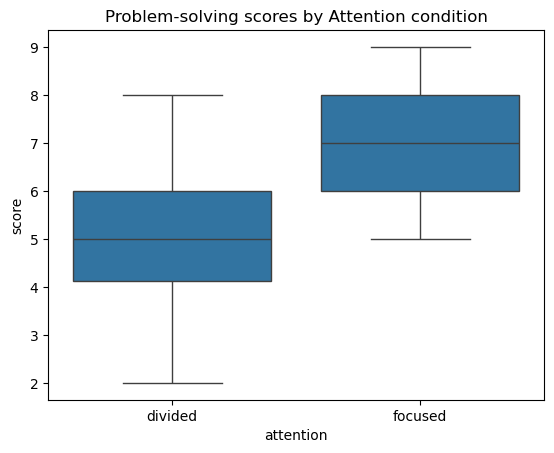

In [40]:
sns.boxplot(data=df , x="attention", y="score")
plt.title("Problem-solving scores by Attention condition")

In [41]:
df.head()

,subject,attention,solutions,score
0,1,divided,1,2.0
1,2,divided,1,3.0
2,3,divided,1,3.0
3,4,divided,1,5.0
4,5,divided,1,4.0


In [44]:
from scipy import stats

divided_sol1 = df[(df["attention"] == "divided") & (df["solutions"] == 1)]["score"]
divided_sol3 = df[(df["attention"] == "divided") & (df["solutions"] == 3)]["score"]
divided_sol2 = df[(df["attention"] == "divided") & (df["solutions"] == 2)]["score"]

f, p = stats.f_oneway(divided_sol1, divided_sol2, divided_sol3)
print(f"f = {f}, p = {p}")

f = 9.253372434017596, p = 0.0008697369175846397


In [46]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

scores = df[df["attention"]=="divided"]["score"]
groups = df[df["attention"]=="divided"]["solutions"]

result = pairwise_tukeyhsd(scores, groups)
print(result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2     0.95  0.227 -0.4432 2.3432  False
     1      3      2.4 0.0006  1.0068 3.7932   True
     2      3     1.45 0.0401  0.0568 2.8432   True
---------------------------------------------------


In [47]:
fscores = df[df["attention"] == "focused"]["score"]
fgroups = df[df["attention"] == "focused"]["solutions"]

fresults = pairwise_tukeyhsd(fscores, fgroups)
print(fresults)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper reject
-------------------------------------------------
     1      2      0.3 0.8475 -1.053 1.653  False
     1      3      0.0    1.0 -1.353 1.353  False
     2      3     -0.3 0.8475 -1.653 1.053  False
-------------------------------------------------


<Axes: xlabel='solutions', ylabel='score'>

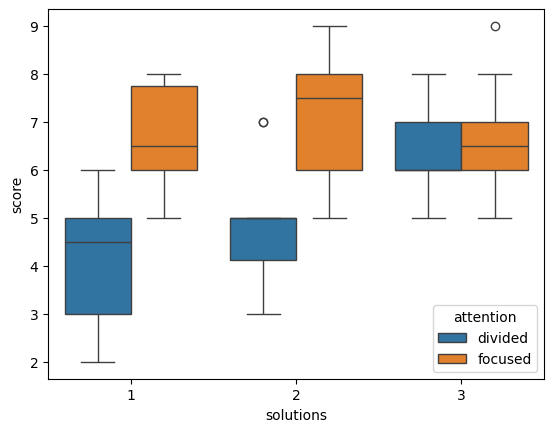

In [48]:
sns.boxplot(data=df, x= "solutions", y= "score", hue = "attention")

In [52]:
df["solutions"].describe()

count    60.000000
mean      2.000000
std       0.823387
min       1.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       3.000000
Name: solutions, dtype: float64

In [56]:
df2 = sns.load_dataset("exercise")
df2.head()

,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest


In [57]:
df2["kind"].unique()

['rest', 'walking', 'running']
Categories (3, object): ['rest', 'walking', 'running']

In [58]:
df2["diet"].unique()

['low fat', 'no fat']
Categories (2, object): ['no fat', 'low fat']

In [59]:
lowfat_group = df2[df2["diet"] == "low fat"]["pulse"]
nofat_group = df2[df2["diet"] == "no fat"]["pulse"] 

from scipy import stats
t, p = stats.ttest_ind(lowfat_group, nofat_group)
print(f"t = {t}, p = {p}")

t = -2.457504273642696, p = 0.015951606961272263


In [65]:
lowfat_group.mean()

np.float64(95.95555555555555)

In [66]:
nofat_group.mean()

np.float64(103.44444444444444)

In [67]:
df2.to_csv("exercise.csv", index = False)

In [70]:
lowfat_rest = df2[(df2["diet"] == "low fat")&(df2["kind"] == "rest")]["pulse"]
nofat_rest = df2[(df2["diet"] == "no fat")&(df2["kind"] == "rest")]["pulse"]

In [72]:
from scipy import stats
t, p = stats.ttest_ind(lowfat_rest, nofat_rest)
print(f"t = {t}, p={p}")

t = -1.4343393820814656, p=0.16255052219660107


In [73]:
running_group = df2[df2["kind"] == "running"]["pulse"]
walking_group = df2[df2["kind"] == "walking"]["pulse"]
rest_group = df2[df2["kind"] == "rest"]["pulse"]

from scipy import stats
f, p = stats.f_oneway(running_group, walking_group, rest_group)
print(f"f = {f}, p = {p}")

f = 31.987037991079976, p = 3.862192785919453e-11


In [75]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

result = pairwise_tukeyhsd(df2["pulse"], df2["kind"])
print(result)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
   rest running  22.2333    0.0  15.2096  29.257   True
   rest walking   4.3667 0.3043   -2.657 11.3904  False
running walking -17.8667    0.0 -24.8904 -10.843   True
-------------------------------------------------------


In [79]:
import statsmodels.formula.api as smf 
model = smf.ols('pulse ~ C(kind) + C(diet) + C(kind):C(diet)', data=df2).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  pulse   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     18.91
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.51e-12
Time:                        19:26:52   Log-Likelihood:                -336.15
No. Observations:                  90   AIC:                             684.3
Df Residuals:                      84   BIC:                             699.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [82]:
all_categories = set(df2["kind"].unique())
in_model = {"walking", "running"}
missing = all_categories - in_model
print(missing)

{'rest'}


In [86]:
print(model.params)

Intercept                                92.333333
C(kind)[T.walking]                        4.600000
C(kind)[T.running]                       28.733333
C(diet)[T.low fat]                       -3.000000
C(kind)[T.walking]:C(diet)[T.low fat]    -0.466667
C(kind)[T.running]:C(diet)[T.low fat]   -13.000000
dtype: float64


In [89]:
parts = "C(kind)[T.walking]".split(".")
print(parts)

['C(kind)[T', 'walking]']


In [91]:
parts[1].split("]")

['walking', '']

In [92]:
parts[1].split("]")[0]

'walking'

In [95]:
df2["time"].unique()

['1 min', '15 min', '30 min']
Categories (3, object): ['1 min', '15 min', '30 min']

In [98]:
df2["time_numeric"] = df2["time"].map({"1 min": 1 , "15 min" : 15, "30 min" : 30})

In [100]:
df2.head()

,Unnamed: 0,id,diet,pulse,time,kind,time_numeric
0,0,1,low fat,85,1 min,rest,1
1,1,1,low fat,85,15 min,rest,15
2,2,1,low fat,88,30 min,rest,30
3,3,2,low fat,90,1 min,rest,1
4,4,2,low fat,92,15 min,rest,15


In [102]:
df2.to_csv("exercise.csv")

In [106]:
from scipy import stats
r, p = stats.pearsonr(df2["pulse"], df2["time_numeric"])
print(f"r = {r}, p = {p}")

r = 0.31040763762053436, p = 0.0029057005546164606


In [115]:
running_df = df2[df2["kind"] == "running"].copy()

In [108]:
r, p = stats.pearsonr(running_df["pulse"], running_df["time_numeric"])
print(f"r = {r}, p = {p}")

r = 0.7011820185294801, p = 1.5883130214006e-05


In [110]:
rest_df = df2[df2["kind"] == "rest"]

from scipy import stats
r, p = stats.pearsonr(rest_df["pulse"], rest_df["time_numeric"])
print(f"r = {r}, p = {p}")

r = 0.08526528716146295, p = 0.6541601919916387


In [112]:
model = smf.ols('pulse ~ time_numeric', data= running_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  pulse   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     14.84
Date:                Sat, 30 May 2026   Prob (F-statistic):           4.50e-05
Time:                        22:19:24   Log-Likelihood:                -117.01
No. Observations:                  30   AIC:                             240.0
Df Residuals:                      27   BIC:                             244.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             96.1000      3

In [113]:
df2["time_numeric"].dtype

CategoricalDtype(categories=[1, 15, 30], ordered=False, categories_dtype=int64)

In [117]:
running_df["time_numeric"] = running_df["time_numeric"].astype(int)

In [119]:
model = smf.ols('pulse ~ time_numeric', data = running_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  pulse   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.474
Method:                 Least Squares   F-statistic:                     27.08
Date:                Sat, 30 May 2026   Prob (F-statistic):           1.59e-05
Time:                        22:57:46   Log-Likelihood:                -117.98
No. Observations:                  30   AIC:                             240.0
Df Residuals:                      28   BIC:                             242.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       97.3372      3.819     25.487   

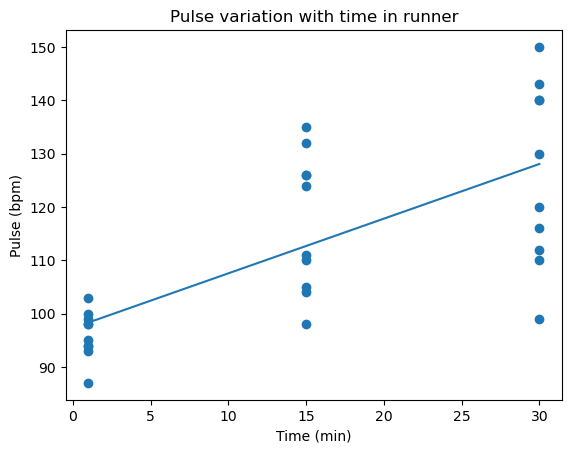

In [127]:
import matplotlib.pyplot as plt 

plt.scatter(running_df["time_numeric"], running_df["pulse"])
plt.plot([1,30],[98.325,128.05])
plt.title("Pulse variation with time in runner")
plt.xlabel("Time (min)")
plt.ylabel("Pulse (bpm)")
 
plt.show()


In [130]:
model = smf.ols('pulse ~ time_numeric + C(diet)', data = running_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  pulse   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.683
Method:                 Least Squares   F-statistic:                     32.25
Date:                Sat, 30 May 2026   Prob (F-statistic):           6.99e-08
Time:                        23:13:23   Log-Likelihood:                -109.82
No. Observations:                  30   AIC:                             225.6
Df Residuals:                      27   BIC:                             229.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            105.3372      3

In [133]:
!pip install pingouin 

In [134]:
df.head()

,subject,attention,solutions,score
0,1,divided,1,2.0
1,2,divided,1,3.0
2,3,divided,1,3.0
3,4,divided,1,5.0
4,5,divided,1,4.0


In [135]:
focused_group1 = df[df["attention"] == "focused"]["score"]
divided_group1 = df[df["attention"] == "divided"]["score"]

import pingouin as pg 
d = pg.compute_effsize(focused_group1, divided_group1, eftype='cohen') 
print(d)

1.2079100267136815
